We begin with a merging our data tables

In [50]:
import pandas as pd
import numpy as np

sdoh_data = pd.read_csv("C:/Users/amyyy/OneDrive/Desktop/MATH_537/FINALPROJ/Data/combined_county_data1.csv")
overdose_data = pd.read_csv("C:/Users/amyyy/OneDrive/Desktop/MATH_537/FINALPROJ/Data/NC_Opioid_Data.txt", sep='\t')
county_combined = pd.read_csv("C:/Users/amyyy/OneDrive/Desktop/MATH_537/FINALPROJ/Data/combined_county_data1.csv")
overdose_data['Year'] = overdose_data['Year'].fillna(0).astype(np.int64)

years = [
    '2018',
    '2019',
    '2020',
    '2021',
    '2022',
    '2023'
]
condition2018 = overdose_data['Year'] == 2018
overdose_2018 = overdose_data[condition2018]

condition2019 = overdose_data['Year'] == 2019
overdose_2019 = overdose_data[condition2019]

condition2020 = overdose_data['Year'] == 2020
overdose_2020 = overdose_data[condition2020]

condition2021 = overdose_data['Year'] == 2021
overdose_2021 = overdose_data[condition2021]

condition2022 = overdose_data['Year'] == 2022
overdose_2022 = overdose_data[condition2022]

condition2023 = overdose_data['Year'] == 2023
overdose_2023 = overdose_data[condition2023]

merged_df_2018 = pd.merge(overdose_2018, county_combined, how="inner", on="County Code")
merged_df_2018.to_csv("C:/Users/amyyy/OneDrive/Desktop/MATH_537/FINALPROJ/Data/merged_2018.csv")
merged_df_2019 = pd.merge(overdose_2019, county_combined, how="inner", on="County Code")
merged_df_2019.to_csv("C:/Users/amyyy/OneDrive/Desktop/MATH_537/FINALPROJ/Data/merged_2019.csv")
merged_df_2020 = pd.merge(overdose_2020, county_combined, how="inner", on="County Code")
merged_df_2020.to_csv("C:/Users/amyyy/OneDrive/Desktop/MATH_537/FINALPROJ/Data/merged_2020.csv")
merged_df_2021 = pd.merge(overdose_2021, county_combined, how="inner", on="County Code")
merged_df_2021.to_csv("C:/Users/amyyy/OneDrive/Desktop/MATH_537/FINALPROJ/Data/merged_2021.csv")
merged_df_2022 = pd.merge(overdose_2022, county_combined, how="inner", on="County Code")
merged_df_2022.to_csv("C:/Users/amyyy/OneDrive/Desktop/MATH_537/FINALPROJ/Data/merged_2022.csv")
merged_df_2023 = pd.merge(overdose_2023, county_combined, how="inner", on="County Code")
merged_df_2023.to_csv("C:/Users/amyyy/OneDrive/Desktop/MATH_537/FINALPROJ/Data/merged_2023.csv")


We now run linear regression on one of the datasets as a test

In [58]:
import numpy as np
from sklearn.model_selection import train_test_split
import scipy.linalg as LA

def mean_squared_error(pred, actual):
        MSE = np.sqrt(((pred - actual)**2).mean())
        return MSE 

df = pd.read_csv("C:/Users/amyyy/OneDrive/Desktop/MATH_537/FINALPROJ/Data/practicelinreg.csv")

y = df['y']
X = df[['x1','x2','x3','x4','x5','x6','x7','x8','x9','x10','x11','x12','x13','x14','x15','x16','x17','x18','x19','x20','x21','x22','x23','x24','x25','x26','x27','x28','x29','x30','x31','x32','x33','x34','x35','x36','x37','x38','x39','x40','x41','x42','x43','x44','x45','x46','x47','x48','x49','x50','x51','x52','x53','x54','x55','x56','x57','x58','x59','x60','x61','x62','x63','x64','x65','x66','x67','x68','x69','x70','x71','x72','x73','x74','x75','x76','x77','x78','x79','x80','x81', 'x82']]

# add a column of ones
X = np.column_stack((np.ones(X.shape[0]), X))

# split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# find the model
alpha = LA.lstsq(X_train,y_train)[0]
for i in range(83):
    print(f"{alpha[i]}x{i}", end=" + ")

y_pred = X_test @ alpha

mse = mean_squared_error(y_test, y_pred)
print(f"\n MSE: {mse}")


792.1017242125592x0 + 15.429190153083972x1 + 1.7333940538727313x2 + -0.9990381033649964x3 + -0.11800156301549414x4 + -0.46091953226192384x5 + -1.5955903904357358x6 + 1.7698606700403563x7 + 2.187087593862233x8 + -6.599103230365622x9 + -15.503871877277684x10 + 16.55043645343626x11 + 1.134670858226117x12 + 0.1946054728547686x13 + 0.47555782915095834x14 + 4.8687250613373525x15 + -7.794213407210926x16 + 3.3899959018833647x17 + 0.5419898299135371x18 + 0.33683818303417645x19 + -0.5097497016112116x20 + -0.8369204882640022x21 + 0.3271707867093364x22 + 0.8465878846248529x23 + 0.2051516468806338x24 + -0.0005655917556950385x25 + 1.2501491060806638x26 + 2.9015107867718495x27 + 1.3319625232675953x28 + -9.437471877557831x29 + 10.769434400827564x30 + -3.3060391801880753x31 + -1.4752489872266132x32 + -1.8307901929615857x33 + -1.2743142160438172x34 + -2.5746474256195655x35 + 1.3003332095743383x36 + 1.8209971384714936x37 + -1.6123074267349993x38 + 3.433304565205592x39 + -5.059408908325966x40 + -0.3372562

ValueError: could not convert string to float: 'Camden'

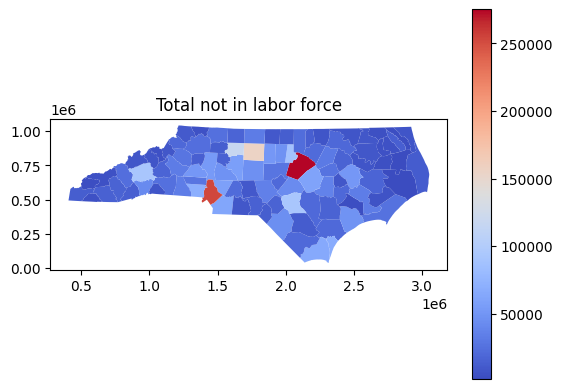

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

counties_shapefile = "C:/Users/amyyy/Downloads/NCDOT_County_Boundaries"
gdf = gpd.read_file("C:/Users/amyyy/Downloads/NCDOT_County_Boundaries/NCDOT_County_Boundaries.shp")
SDOH_data = pd.read_csv("C:/Users/amyyy/OneDrive/Desktop/MATH_537/FINALPROJ/Data/combined_county_data2.csv")

# CDC data formatting 
SDOH_data.rename(columns={'County': 'CountyName'}, inplace=True)
SDOH_data['CountyName'] = SDOH_data['CountyName'].str.replace(r' County, NC', '', regex=True)

# Merge CDC mortality data and ACS SDOH data with the shapefile
merged = gdf.merge(SDOH_data, left_on='CountyName', right_on='CountyName', how='left')

# Plotting mortality rates by county (for example)
merged.plot(column='Total not in labor force', cmap='coolwarm', legend=True)
plt.title('Total not in labor force')
# plt.show()

# Correlation matrix for numerical columns
corr_matrix = merged.corr()
print(corr_matrix)

# # Visualize correlation matrix with a heatmap
# import seaborn as sns

# sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
# plt.title('Correlation Matrix')
# plt.show()




In [ ]:
import geopandas as gpd

gdf = gpd.read_file("C:/Users/amyyy/Downloads/NCDOT_County_Boundaries/NCDOT_County_Boundaries.shp")

print(gdf)


   OBJECTID  FIPS CountyName UpperCount SapCountyI  DOTDistric  DOTDivisio  \
0         1    29     Camden     CAMDEN        015           1           1   
1         2    73      Gates      GATES        037           1           1   
2         3    97    Iredell    IREDELL        049           2          12   
3         4   193     Wilkes     WILKES        097           3          11   
4         5   179      Union      UNION        090           3          10   

   SAP_CNTY_N  CNTY_NBR  DSTRCT_NBR  DIV_NBR     NAME  SHPNumber  \
0          15        14           1        1   Camden         15   
1          37        36           1        1    Gates         37   
2          49        48           2       12  Iredell         49   
3          97        96           3       11   Wilkes         97   
4          90        89           3       10    Union         90   

     ShapeSTAre     ShapeSTLen  \
0  8.650426e+09  680450.731781   
1  9.640705e+09  444604.369559   
2  1.667062e+10  639